# Full-Trace Analysis

Each observation is one complete 20-prompt continuous trace (no inter-trial reset).

**Analyses:**
1. Per-feature: descriptive stats, t-test, and MWU on each feature independently
2. Joint 5D: treat each trace as a point in 5D feature space, compute centroids,
   cross/within distances, and a permutation test for multivariate separation

In [62]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

# ── Configuration ──────────────────────────────────────────────────────────
BASE_DIR  = Path.home() / 'Desktop' / 'mccviahat'
DATA_DIR  = BASE_DIR / 'data' / 'fulltrace'

# The 5 features of interest on core_power.throttle
FEATURES = [
    'core_power.throttle__mean_rate',
    'core_power.throttle__slope',
    'core_power.throttle__variance',
    'core_power.throttle__spectral_entropy',
    'core_power.throttle__lz_complexity',
    'core_power.throttle__burst_rate',
    'core_power.throttle__burst_clustering',
    'core_power.throttle__perm_entropy',
    'core_power.throttle__p90_p10',
]

# Short names for display — works whether feature has __ prefix or not
SHORT = {f: f.split('__')[-1] for f in FEATURES}

SEED = 42
N_PERMUTATIONS = 10_000
N_BOOTSTRAP    = 5_000

print('Configuration OK')

Configuration OK


## §1 — Load data

In [63]:
# Load all *_whole.csv files from the fulltrace directory
whole_csvs = sorted(DATA_DIR.glob('*_whole.csv'))
print(f'Found {len(whole_csvs)} whole-trace CSVs:')
for p in whole_csvs:
    print(f'  {p.name}')

dfs = [pd.read_csv(p) for p in whole_csvs]
df = pd.concat(dfs, ignore_index=True)

# Normalise label column
if 'condition' not in df.columns and 'label' in df.columns:
    df['condition'] = df['label']

n_e = (df.condition == 'emotional').sum()
n_n = (df.condition == 'neutral').sum()

print(f'\nTotal traces: {len(df)}  (emotional={n_e}, neutral={n_n})')
print(f'\nFeature availability:')
available = []
for f in FEATURES:
    ok = f in df.columns
    print(f'  {"✓" if ok else "✗"} {SHORT[f]}')
    if ok:
        available.append(f)
FEATURES = available
assert len(FEATURES) > 0, 'No features found!'

# Show raw data
display_cols = ['run_label', 'condition', 'n_prompts', 'total_ms'] + FEATURES
display_cols = [c for c in display_cols if c in df.columns]
df[display_cols]

Found 12 whole-trace CSVs:
  226_1e_whole.csv
  226_1n_whole.csv
  230_1e_whole.csv
  230_1n_whole.csv
  230_2e_whole.csv
  230_2n_whole.csv
  244_1e_whole.csv
  244_1n_whole.csv
  244_2e_whole.csv
  244_2n_whole.csv
  249_1e_whole.csv
  249_1n_whole.csv

Total traces: 12  (emotional=6, neutral=6)

Feature availability:
  ✓ mean_rate
  ✓ slope
  ✓ variance
  ✓ spectral_entropy
  ✓ lz_complexity
  ✓ burst_rate
  ✓ burst_clustering
  ✓ perm_entropy
  ✓ p90_p10


,run_label,condition,n_prompts,total_ms,core_power.throttle__mean_rate,core_power.throttle__slope,core_power.throttle__variance,core_power.throttle__spectral_entropy,core_power.throttle__lz_complexity,core_power.throttle__burst_rate,core_power.throttle__burst_clustering,core_power.throttle__perm_entropy,core_power.throttle__p90_p10
0,226_1e,emotional,20,1.136113e+06,11516.913083,10.663675,2.969384e+13,0.923503,7.372588,7.075883,0.185731,0.999621,11468019.4
1,226_1n,neutral,20,1.171358e+06,11113.640153,8.047516,4.111321e+13,0.939002,7.360098,4.945540,0.157262,0.999511,12053860.4
2,230_1e,emotional,20,1.109613e+06,12686.036081,7.639366,3.305301e+13,0.901756,7.062686,7.544974,0.187654,0.999563,12504862.8
3,230_1n,neutral,20,1.148851e+06,11947.337048,7.840210,3.173567e+13,0.883331,7.007756,7.571043,0.191560,0.999479,13165071.6
4,230_2e,emotional,20,1.112621e+06,12550.367578,17.305520,3.160462e+13,0.899762,6.924223,7.704332,0.191549,0.999414,12414164.0
5,230_2n,neutral,20,1.149388e+06,11840.023908,7.189987,3.179116e+13,0.887933,6.989270,7.223847,0.186313,0.999438,12954301.9
6,244_1e,emotional,20,1.114639e+06,12078.317396,11.570406,3.321886e+13,0.913752,7.184766,7.175415,0.176014,0.999728,12245813.7
7,244_1n,neutral,20,1.171047e+06,10874.851346,6.841111,2.928887e+13,0.912283,7.374116,6.726458,0.176875,0.999621,11776246.8
8,244_2e,emotional,20,1.129645e+06,11506.166698,9.181400,2.871063e+13,0.921140,7.546388,6.909251,0.170811,0.999691,11189534.8
9,244_2n,neutral,20,1.168310e+06,10971.342372,13.405446,2.996497e+13,0.911773,7.284098,6.919398,0.180171,0.999644,12132096.2


## §2 — Per-feature univariate tests

For each feature independently:
- Descriptive statistics
- Two-sample t-test (tests difference in means, assumes normality)
- Mann-Whitney U (tests distributional shift, no assumptions)

In [64]:
e_mask = df['condition'] == 'emotional'
n_mask = df['condition'] == 'neutral'

results = []

for feat in FEATURES:
    e_vals = df.loc[e_mask, feat].dropna().values
    n_vals = df.loc[n_mask, feat].dropna().values
    name = SHORT[feat]

    e_mean, e_std = np.mean(e_vals), np.std(e_vals, ddof=1)
    n_mean, n_std = np.mean(n_vals), np.std(n_vals, ddof=1)
    direction = '↑E' if e_mean > n_mean else '↑N'

    # Cohen's d
    pooled_std = np.sqrt((e_std**2 + n_std**2) / 2)
    cohens_d = abs(e_mean - n_mean) / pooled_std if pooled_std > 0 else np.nan

    # t-test
    t_stat, t_p = ttest_ind(e_vals, n_vals, equal_var=False)

    # MWU
    u_stat, mwu_p = mannwhitneyu(e_vals, n_vals, alternative='two-sided')

    results.append({
        'feature': name, 'direction': direction,
        'e_mean': e_mean, 'e_std': e_std,
        'n_mean': n_mean, 'n_std': n_std,
        'cohens_d': cohens_d,
        't_stat': t_stat, 't_p': t_p,
        'U': u_stat, 'mwu_p': mwu_p,
    })

res_df = pd.DataFrame(results)

# Bonferroni correction
n_tests = len(results)
res_df['t_p_corr'] = (res_df['t_p'] * n_tests).clip(upper=1.0)
res_df['mwu_p_corr'] = (res_df['mwu_p'] * n_tests).clip(upper=1.0)

print(f'Per-feature tests (n_E={n_e}, n_N={n_n}, Bonferroni k={n_tests})')
print('=' * 110)
print(f'{"Feature":>20s}  {"Dir":>3s}  {"E mean":>12s}  {"N mean":>12s}  '
      f'{"Cohen d":>8s}  {"t":>8s}  {"t p_corr":>10s}  {"U":>8s}  {"MWU p_corr":>10s}')
print('-' * 110)
for _, r in res_df.iterrows():
    sig_t = '*' if r['t_p_corr'] < 0.05 else ' '
    sig_m = '*' if r['mwu_p_corr'] < 0.05 else ' '
    print(f'{r["feature"]:>20s}  {r["direction"]:>3s}  '
          f'{r["e_mean"]:12.4f}  {r["n_mean"]:12.4f}  '
          f'{r["cohens_d"]:8.4f}  {r["t_stat"]:8.3f}  '
          f'{r["t_p_corr"]:10.4f}{sig_t} '
          f'{r["U"]:8.1f}  '
          f'{r["mwu_p_corr"]:10.4f}{sig_m}')
print()
print('* = significant after Bonferroni correction (p_corr < 0.05)')

Per-feature tests (n_E=6, n_N=6, Bonferroni k=9)
             Feature  Dir        E mean        N mean   Cohen d         t    t p_corr         U  MWU p_corr
--------------------------------------------------------------------------------------------------------------
           mean_rate   ↑E    11977.0950    11380.8635    1.1851     2.053      0.6121      27.0      1.0000 
               slope   ↑E       10.4364        8.4372    0.6141     1.064      1.0000      24.0      1.0000 
            variance   ↑N  31567923301419.2383  33291563798301.0938    0.5006    -0.867      1.0000      15.0      1.0000 
    spectral_entropy   ↑E        0.9159        0.9102    0.3163     0.548      1.0000      21.0      1.0000 
       lz_complexity   ↑E        7.2350        7.1930    0.2098     0.363      1.0000      20.0      1.0000 
          burst_rate   ↑E        7.0247        6.5667    0.5494     0.952      1.0000      23.0      1.0000 
    burst_clustering   ↑E        0.1796        0.1779    0.1475 

In [65]:
# Detailed per-feature printout
for feat in FEATURES:
    e_vals = df.loc[e_mask, feat].dropna().values
    n_vals = df.loc[n_mask, feat].dropna().values
    name = SHORT[feat]
    r = res_df[res_df.feature == name].iloc[0]

    print(f'\n{"=" * 60}')
    print(f'  {name}  ({r["direction"]})')
    print(f'{"=" * 60}')
    print(f'  Emotional : n={len(e_vals):3d}  mean={r["e_mean"]:.4f}  SD={r["e_std"]:.4f}')
    print(f'  Neutral   : n={len(n_vals):3d}  mean={r["n_mean"]:.4f}  SD={r["n_std"]:.4f}')
    print(f'  Cohen\'s d : {r["cohens_d"]:.4f}')
    print(f'  t-test    : t={r["t_stat"]:.4f}  p={r["t_p"]:.6f}  p_corr={r["t_p_corr"]:.6f}')
    print(f'  MWU       : U={r["U"]:.1f}  p={r["mwu_p"]:.6f}  p_corr={r["mwu_p_corr"]:.6f}')
    print(f'  E values  : {np.array2string(e_vals, precision=2, separator=", ")}')
    print(f'  N values  : {np.array2string(n_vals, precision=2, separator=", ")}')


  mean_rate  (↑E)
  Emotional : n=  6  mean=11977.0950  SD=543.9897
  Neutral   : n=  6  mean=11380.8635  SD=458.6006
  Cohen's d : 1.1851
  t-test    : t=2.0526  p=0.068008  p_corr=0.612073
  MWU       : U=27.0  p=0.179654  p_corr=1.000000
  E values  : [11516.91, 12686.04, 12550.37, 12078.32, 11506.17, 11524.77]
  N values  : [11113.64, 11947.34, 11840.02, 10874.85, 10971.34, 11537.99]

  slope  (↑E)
  Emotional : n=  6  mean=10.4364  SD=3.8828
  Neutral   : n=  6  mean=8.4372  SD=2.4735
  Cohen's d : 0.6141
  t-test    : t=1.0637  p=0.316800  p_corr=1.000000
  MWU       : U=24.0  p=0.393939  p_corr=1.000000
  E values  : [10.66,  7.64, 17.31, 11.57,  9.18,  6.26]
  N values  : [ 8.05,  7.84,  7.19,  6.84, 13.41,  7.3 ]

  variance  (↑N)
  Emotional : n=  6  mean=31567923301419.2383  SD=1951311981962.0054
  Neutral   : n=  6  mean=33291563798301.0938  SD=4461205384007.8193
  Cohen's d : 0.5006
  t-test    : t=-0.8671  p=0.415257  p_corr=1.000000
  MWU       : U=15.0  p=0.699134  p_c

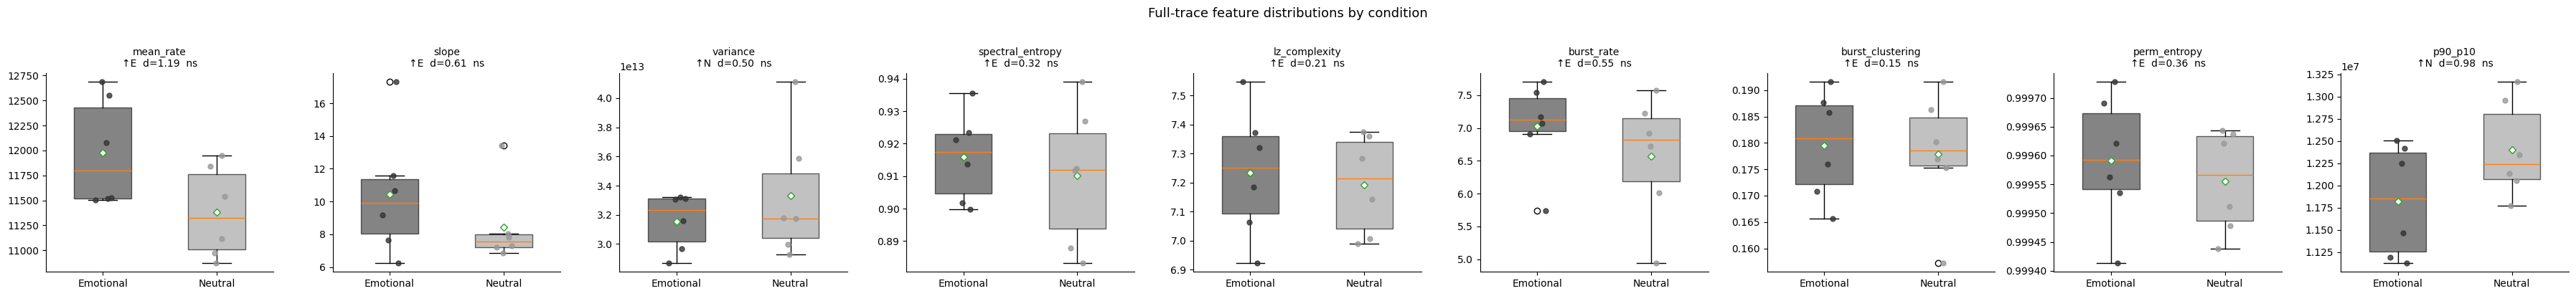

In [66]:
# Visualise per-feature distributions
n_feat = len(FEATURES)
fig, axes = plt.subplots(1, n_feat, figsize=(4 * n_feat, 4), sharey=False)
if n_feat == 1:
    axes = [axes]

for ax, feat in zip(axes, FEATURES):
    e_vals = df.loc[e_mask, feat].dropna().values
    n_vals = df.loc[n_mask, feat].dropna().values
    name = SHORT[feat]

    positions = [0, 1]
    bp = ax.boxplot([e_vals, n_vals], positions=positions, widths=0.5,
                    patch_artist=True, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='white', markersize=5))
    bp['boxes'][0].set_facecolor('#333333')
    bp['boxes'][1].set_facecolor('#999999')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_alpha(0.6)

    # Overlay individual points
    jitter = 0.08
    rng_j = np.random.default_rng(42)
    ax.scatter(np.zeros(len(e_vals)) + rng_j.uniform(-jitter, jitter, len(e_vals)),
               e_vals, color='#333333', s=25, zorder=5, alpha=0.8)
    ax.scatter(np.ones(len(n_vals)) + rng_j.uniform(-jitter, jitter, len(n_vals)),
               n_vals, color='#999999', s=25, zorder=5, alpha=0.8)

    r = res_df[res_df.feature == name].iloc[0]
    sig = '***' if r['mwu_p_corr'] < 0.001 else '**' if r['mwu_p_corr'] < 0.01 else '*' if r['mwu_p_corr'] < 0.05 else 'ns'
    ax.set_title(f'{name}\n{r["direction"]}  d={r["cohens_d"]:.2f}  {sig}', fontsize=10)
    ax.set_xticks(positions)
    ax.set_xticklabels(['Emotional', 'Neutral'])
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Full-trace feature distributions by condition', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## §2b — Per-feature intra/inter group distances

For each feature independently, compute:
- Mean within-emotional distance (intra-E)
- Mean within-neutral distance (intra-N)
- Mean cross-condition distance (inter)
- Ratio inter/intra and t-test on the distances

In [67]:
# ── Per-feature 1D intra/inter group distance analysis ──────────────────
print('Per-feature intra/inter group distances')
print('=' * 100)
print(f'{"Feature":>20s}  {"Intra-E":>10s}  {"Intra-N":>10s}  '
      f'{"Intra(avg)":>10s}  {"Inter":>10s}  {"Inter/Intra":>12s}  {"Dir":>3s}')
print('-' * 100)

dist_1d_results = []

for feat in FEATURES:
    name = SHORT[feat]
    e_vals = df.loc[e_mask, feat].dropna().values
    n_vals = df.loc[n_mask, feat].dropna().values

    # Within-emotional: all unique pairs |xi - xj|
    intra_e = []
    for i in range(len(e_vals)):
        for j in range(i + 1, len(e_vals)):
            intra_e.append(abs(e_vals[i] - e_vals[j]))
    intra_e = np.array(intra_e) if intra_e else np.array([np.nan])

    # Within-neutral: all unique pairs
    intra_n = []
    for i in range(len(n_vals)):
        for j in range(i + 1, len(n_vals)):
            intra_n.append(abs(n_vals[i] - n_vals[j]))
    intra_n = np.array(intra_n) if intra_n else np.array([np.nan])

    # Cross-condition: every e vs every n
    inter = []
    for ev in e_vals:
        for nv in n_vals:
            inter.append(abs(ev - nv))
    inter = np.array(inter) if inter else np.array([np.nan])

    mean_ie = np.mean(intra_e)
    mean_in = np.mean(intra_n)
    mean_intra = np.mean(np.concatenate([intra_e, intra_n]))
    mean_inter = np.mean(inter)
    ratio = mean_inter / mean_intra if mean_intra > 0 else np.nan

    r = res_df[res_df.feature == name].iloc[0]
    direction = r['direction']

    dist_1d_results.append({
        'feature': name, 'direction': direction,
        'intra_e': mean_ie, 'intra_n': mean_in,
        'intra_avg': mean_intra, 'inter': mean_inter,
        'ratio': ratio,
    })

    print(f'{name:>20s}  {mean_ie:10.4f}  {mean_in:10.4f}  '
          f'{mean_intra:10.4f}  {mean_inter:10.4f}  {ratio:12.4f}  {direction:>3s}')

dist_1d_df = pd.DataFrame(dist_1d_results)

print()
print('Interpretation:')
print('  Inter/Intra > 1.0 → cross-condition pairs are farther apart than within-condition pairs')
print('  Inter/Intra ≈ 1.0 → conditions overlap completely')

Per-feature intra/inter group distances
             Feature     Intra-E     Intra-N  Intra(avg)       Inter   Inter/Intra  Dir
----------------------------------------------------------------------------------------------------
           mean_rate    636.8839    559.5213    598.2026    725.8145        1.2133   ↑E
               slope      4.5676      2.3957      3.4816      3.5687        1.0250   ↑E
            variance  2285848223987.3804  5123253506998.6465  3704550865493.0142  3590981584331.7534        0.9693   ↑N
    spectral_entropy      0.0168      0.0264      0.0216      0.0200        0.9292   ↑E
       lz_complexity      0.2783      0.2082      0.2432      0.2133        0.8769   ↑E
          burst_rate      0.7891      1.1300      0.9596      0.8948        0.9325   ↑E
    burst_clustering      0.0127      0.0138      0.0133      0.0116        0.8766   ↑E
        perm_entropy      0.0001      0.0001      0.0001      0.0001        0.9254   ↑E
             p90_p10  754640.7267  

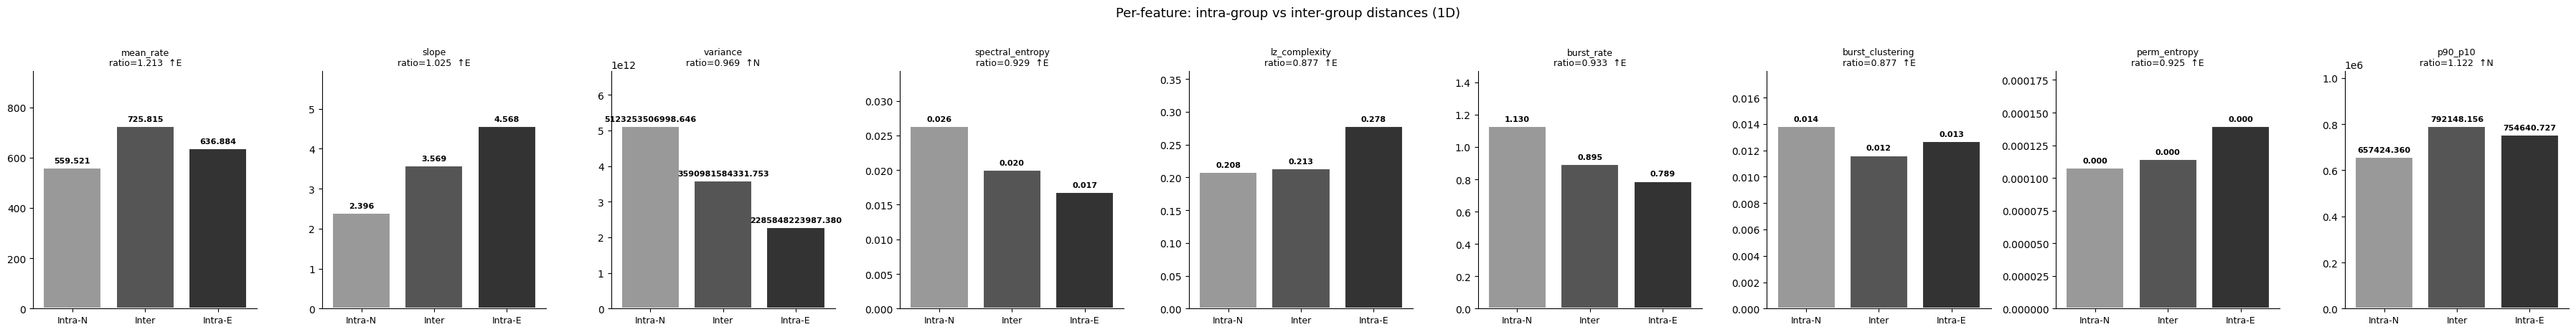

In [68]:
# Visualise per-feature intra vs inter distances
n_feat = len(FEATURES)
fig, axes = plt.subplots(1, n_feat, figsize=(4 * n_feat, 4.5), sharey=False)
if n_feat == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, dist_1d_df.iterrows()):
    vals = [row['intra_n'], row['inter'], row['intra_e']]
    labels = ['Intra-N', 'Inter', 'Intra-E']
    colors = ['#999999', '#555555', '#333333']
    bars = ax.bar(range(3), vals, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(f'{row["feature"]}\nratio={row["ratio"]:.3f}  {row["direction"]}', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, max(vals) * 1.3)

fig.suptitle('Per-feature: intra-group vs inter-group distances (1D)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## §2c — Top-3 joint intra/inter distance analysis

Select the three features with the highest inter/intra ratio from §2b,
standardise them, and compute intra/inter distances in 3D space.
This tests whether combining the most discriminating features
produces a stronger separation than any single feature alone.

In [69]:
# ── Top-3 joint intra/inter distance analysis ──────────────────────────────
top3 = dist_1d_df.sort_values('ratio', ascending=False).head(3)
top3_names = top3['feature'].tolist()
top3_full = [f for f in FEATURES if SHORT[f] in top3_names]

print(f'Top 3 features by inter/intra ratio:')
for _, r in top3.iterrows():
    print(f'  {r["feature"]:>20s}  ratio={r["ratio"]:.4f}  {r["direction"]}')
print()

# Build 3D feature matrix (standardised)
X3_raw = df[top3_full].values
scaler3 = StandardScaler()
X3 = scaler3.fit_transform(X3_raw)

X3_e = X3[e_mask.values]
X3_n = X3[n_mask.values]

# Centroids
c3_e = X3_e.mean(axis=0)
c3_n = X3_n.mean(axis=0)
c3_dist = np.linalg.norm(c3_e - c3_n)

# Pairwise distances
cross_3d = cdist(X3_e, X3_n, metric='euclidean').ravel()
within_e_3d = cdist(X3_e, X3_e, metric='euclidean')
within_e_3d = within_e_3d[np.triu_indices_from(within_e_3d, k=1)]
within_n_3d = cdist(X3_n, X3_n, metric='euclidean')
within_n_3d = within_n_3d[np.triu_indices_from(within_n_3d, k=1)]
within_all_3d = np.concatenate([within_e_3d, within_n_3d])

mean_cross_3d = np.mean(cross_3d)
mean_within_e_3d = np.mean(within_e_3d)
mean_within_n_3d = np.mean(within_n_3d)
mean_within_3d = np.mean(within_all_3d)
ratio_3d = mean_cross_3d / mean_within_3d if mean_within_3d > 0 else np.nan

print(f'3D Joint distances (standardised):')
print(f'  Centroid distance          : {c3_dist:.4f}')
print(f'  E[d(Xe, Xn)]  inter        : {mean_cross_3d:.4f}')
print(f'  E[d(Xe, Xe\')]  intra-E      : {mean_within_e_3d:.4f}')
print(f'  E[d(Xn, Xn\')]  intra-N      : {mean_within_n_3d:.4f}')
print(f'  E[d]           intra(avg)   : {mean_within_3d:.4f}')
print(f'  Inter / Intra              : {ratio_3d:.4f}')
print()

# Permutation test in 3D
rng3 = np.random.default_rng(SEED)
observed_3d = c3_dist
n_total_3d = len(X3)
n_e_3d = X3_e.shape[0]
null_3d = np.empty(N_PERMUTATIONS)
for i in range(N_PERMUTATIONS):
    perm = rng3.permutation(n_total_3d)
    null_3d[i] = np.linalg.norm(
        X3[perm[:n_e_3d]].mean(axis=0) - X3[perm[n_e_3d:]].mean(axis=0))

p_perm_3d = (np.sum(null_3d >= observed_3d) + 1) / (N_PERMUTATIONS + 1)

print(f'Permutation test (3D, {N_PERMUTATIONS:,} iterations):')
print(f'  Observed centroid distance : {observed_3d:.4f}')
print(f'  Null mean ± SD            : {np.mean(null_3d):.4f} ± {np.std(null_3d):.4f}')
print(f'  p-value                   : {p_perm_3d:.4f}')
print(f'  Significant (p < 0.05)    : {p_perm_3d < 0.05}')

Top 3 features by inter/intra ratio:
             mean_rate  ratio=1.2133  ↑E
               p90_p10  ratio=1.1220  ↑N
                 slope  ratio=1.0250  ↑E

3D Joint distances (standardised):
  Centroid distance          : 1.5783
  E[d(Xe, Xn)]  inter        : 2.5581
  E[d(Xe, Xe')]  intra-E      : 2.4737
  E[d(Xn, Xn')]  intra-N      : 1.8934
  E[d]           intra(avg)   : 2.1835
  Inter / Intra              : 1.1716

Permutation test (3D, 10,000 iterations):
  Observed centroid distance : 1.5783
  Null mean ± SD            : 0.9659 ± 0.3720
  p-value                   : 0.0673
  Significant (p < 0.05)    : False


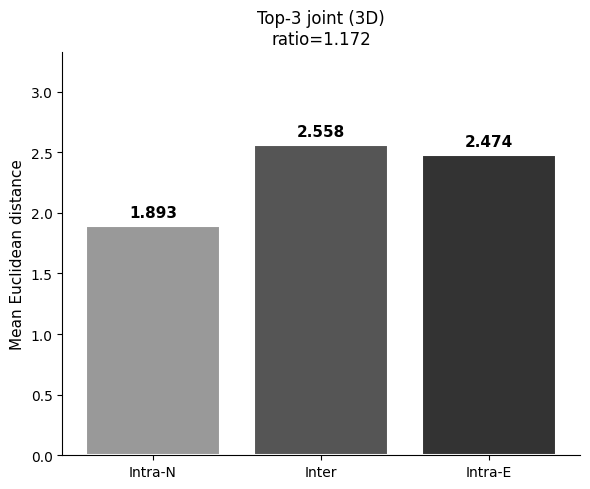

In [70]:
# Visualise top-3 3D intra vs inter distances
categories = ['Intra-N', 'Inter', 'Intra-E']
vals_3d = [mean_within_n_3d, mean_cross_3d, mean_within_e_3d]
colors = ['#999999', '#555555', '#333333']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(range(3), vals_3d, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals_3d):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals_3d)*0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(range(3))
ax.set_xticklabels(categories, fontsize=10)
ax.set_title(f'Top-3 joint (3D)\nratio={ratio_3d:.3f}', fontsize=12)
ax.set_ylabel('Mean Euclidean distance', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(vals_3d) * 1.3)
plt.tight_layout()
plt.show()

## §3 — Joint 5D analysis

Treat each trace as a point in 5D feature space (standardised).
Compute centroids, within-condition distances, cross-condition distances,
and run a permutation test for multivariate separation.

In [71]:
# Build the feature matrix
X_raw = df[FEATURES].values
y = (df['condition'] == 'emotional').astype(int).values  # 1=emotional, 0=neutral

# Standardise (zero mean, unit variance) so all features contribute equally
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

X_e = X[y == 1]
X_n = X[y == 0]

print(f'Feature matrix: {X.shape[0]} traces × {X.shape[1]} features')
print(f'  Emotional: {X_e.shape[0]} traces')
print(f'  Neutral:   {X_n.shape[0]} traces')

Feature matrix: 12 traces × 9 features
  Emotional: 6 traces
  Neutral:   6 traces


In [72]:
# ── Centroids ──────────────────────────────────────────────────────────────
centroid_e = X_e.mean(axis=0)
centroid_n = X_n.mean(axis=0)
centroid_dist = np.linalg.norm(centroid_e - centroid_n)

print('5D Centroids (standardised space):')
print(f'{"Feature":>25s}  {"Emotional":>10s}  {"Neutral":>10s}  {"Diff":>10s}')
print('-' * 60)
for i, feat in enumerate(FEATURES):
    diff = centroid_e[i] - centroid_n[i]
    print(f'{SHORT[feat]:>25s}  {centroid_e[i]:10.4f}  {centroid_n[i]:10.4f}  {diff:+10.4f}')
print(f'\nEuclidean distance between centroids: {centroid_dist:.4f}')

5D Centroids (standardised space):
                  Feature   Emotional     Neutral        Diff
------------------------------------------------------------
                mean_rate      0.5445     -0.5445     +1.0889
                    slope      0.3188     -0.3188     +0.6376
                 variance     -0.2644      0.2644     -0.5289
         spectral_entropy      0.1707     -0.1707     +0.3414
            lz_complexity      0.1142     -0.1142     +0.2283
               burst_rate      0.2881     -0.2881     +0.5763
         burst_clustering      0.0805     -0.0805     +0.1610
             perm_entropy      0.1919     -0.1919     +0.3837
                  p90_p10     -0.4740      0.4740     -0.9480

Euclidean distance between centroids: 1.8560


In [73]:
# ── Pairwise distances ─────────────────────────────────────────────────────
# Cross-condition: every emotional trace vs every neutral trace
cross_dists = cdist(X_e, X_n, metric='euclidean').ravel()

# Within-emotional: all pairs
within_e_dists = cdist(X_e, X_e, metric='euclidean')
within_e_dists = within_e_dists[np.triu_indices_from(within_e_dists, k=1)]

# Within-neutral: all pairs
within_n_dists = cdist(X_n, X_n, metric='euclidean')
within_n_dists = within_n_dists[np.triu_indices_from(within_n_dists, k=1)]

within_all_dists = np.concatenate([within_e_dists, within_n_dists])

mean_cross = np.mean(cross_dists)
mean_within_e = np.mean(within_e_dists)
mean_within_n = np.mean(within_n_dists)
mean_within = np.mean(within_all_dists)

print('5D Pairwise distances:')
print('=' * 60)
print(f'  Cross-condition  E[d(Xe, Xn)]  = {mean_cross:.4f}  (median {np.median(cross_dists):.4f})')
print(f'  Within emotional E[d(Xe, Xe\')]  = {mean_within_e:.4f}  (median {np.median(within_e_dists):.4f})')
print(f'  Within neutral   E[d(Xn, Xn\')]  = {mean_within_n:.4f}  (median {np.median(within_n_dists):.4f})')
print(f'  Within combined                = {mean_within:.4f}  (median {np.median(within_all_dists):.4f})')

ratio_cross_within = mean_cross / mean_within if mean_within > 0 else np.nan
ratio_centroid_within = centroid_dist / mean_within if mean_within > 0 else np.nan

print(f'\nKey ratios:')
print(f'  Cross / within             = {ratio_cross_within:.4f}  (>1 → conditions separable)')
print(f'  Centroid dist / within     = {ratio_centroid_within:.4f}  (signal-to-noise)')

5D Pairwise distances:
  Cross-condition  E[d(Xe, Xn)]  = 4.2089  (median 4.1765)
  Within emotional E[d(Xe, Xe')]  = 4.1286  (median 3.8362)
  Within neutral   E[d(Xn, Xn')]  = 4.2599  (median 4.3414)
  Within combined                = 4.1942  (median 4.2541)

Key ratios:
  Cross / within             = 1.0035  (>1 → conditions separable)
  Centroid dist / within     = 0.4425  (signal-to-noise)


In [74]:
# ── Permutation test ───────────────────────────────────────────────────────
# H0: the labels 'emotional' and 'neutral' are interchangeable.
# Test statistic: Euclidean distance between the two centroids in 5D.
# Shuffle labels N_PERMUTATIONS times and compute the null distribution.

rng = np.random.default_rng(SEED)
observed = centroid_dist

null_dists = np.empty(N_PERMUTATIONS)
n_total = len(X)
n_e_count = X_e.shape[0]

for i in range(N_PERMUTATIONS):
    perm = rng.permutation(n_total)
    X_perm_e = X[perm[:n_e_count]]
    X_perm_n = X[perm[n_e_count:]]
    null_dists[i] = np.linalg.norm(X_perm_e.mean(axis=0) - X_perm_n.mean(axis=0))

p_perm = (np.sum(null_dists >= observed) + 1) / (N_PERMUTATIONS + 1)

print(f'Permutation test ({N_PERMUTATIONS:,} iterations):')
print(f'  Observed centroid distance : {observed:.4f}')
print(f'  Null mean ± SD            : {np.mean(null_dists):.4f} ± {np.std(null_dists):.4f}')
print(f'  Null 95th percentile      : {np.percentile(null_dists, 95):.4f}')
print(f'  Null 99th percentile      : {np.percentile(null_dists, 99):.4f}')
print(f'  p-value                   : {p_perm:.4f}')
print(f'  Significant (p < 0.05)    : {p_perm < 0.05}')

Permutation test (10,000 iterations):
  Observed centroid distance : 1.8560
  Null mean ± SD            : 1.7096 ± 0.5576
  Null 95th percentile      : 2.7264
  Null 99th percentile      : 3.3309
  p-value                   : 0.3606
  Significant (p < 0.05)    : False


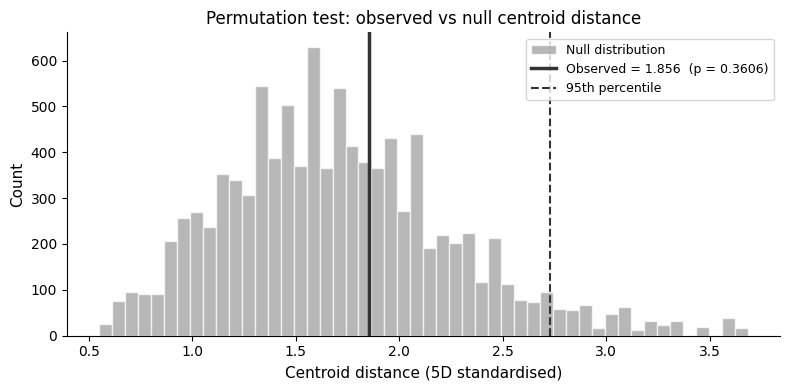

In [75]:
# Visualise the permutation null distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null_dists, bins=50, color='#999999', edgecolor='white', alpha=0.7,
        label='Null distribution')
ax.axvline(observed, color='#333333', lw=2.5, ls='-',
           label=f'Observed = {observed:.3f}  (p = {p_perm:.4f})')
ax.axvline(np.percentile(null_dists, 95), color='#333333', lw=1.5, ls='--',
           label='95th percentile')
ax.set_xlabel('Centroid distance (5D standardised)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Permutation test: observed vs null centroid distance', fontsize=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [76]:
# ── Bootstrap CI for centroid distance ─────────────────────────────────────
rng_b = np.random.default_rng(SEED)
boot_dists = np.empty(N_BOOTSTRAP)

for i in range(N_BOOTSTRAP):
    e_boot = X_e[rng_b.choice(X_e.shape[0], size=X_e.shape[0], replace=True)]
    n_boot = X_n[rng_b.choice(X_n.shape[0], size=X_n.shape[0], replace=True)]
    boot_dists[i] = np.linalg.norm(e_boot.mean(axis=0) - n_boot.mean(axis=0))

ci_lo, ci_hi = np.percentile(boot_dists, [2.5, 97.5])

print(f'Bootstrap 95% CI for centroid distance:')
print(f'  [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'  Bootstrap mean: {np.mean(boot_dists):.4f}')

Bootstrap 95% CI for centroid distance:
  [1.7260, 3.6600]
  Bootstrap mean: 2.4157


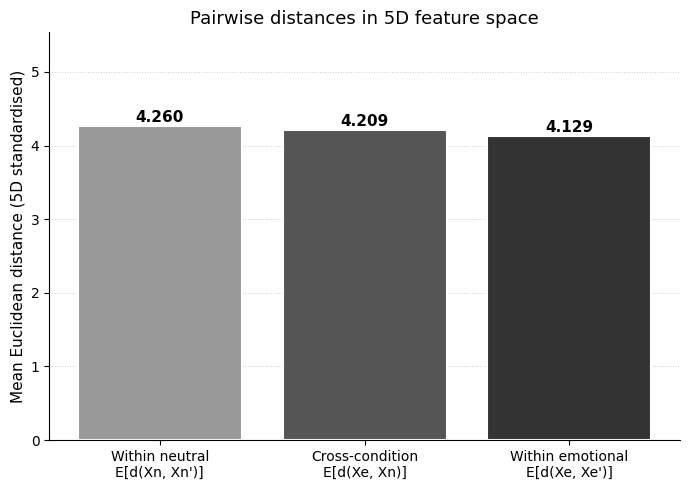

In [77]:
# ── Pairwise distance comparison plot ──────────────────────────────────────
categories = ['Within neutral\nE[d(Xn, Xn\')]', 'Cross-condition\nE[d(Xe, Xn)]',
              'Within emotional\nE[d(Xe, Xe\')]']
vals = [mean_within_n, mean_cross, mean_within_e]
colors = ['#999999', '#555555', '#333333']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(range(3), vals, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(range(3))
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Mean Euclidean distance (5D standardised)', fontsize=11)
ax.set_title('Pairwise distances in 5D feature space', fontsize=13)
ax.set_ylim(0, max(vals) * 1.3)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='#cccccc', zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## §4 — Summary

In [78]:
print('=' * 70)
print('FULL-TRACE ANALYSIS SUMMARY')
print('=' * 70)
print(f'Traces         : {n_e} emotional, {n_n} neutral')
print(f'Features       : {len(FEATURES)}')
print()

print('PER-FEATURE RESULTS (Bonferroni-corrected):')
print(f'{"Feature":>20s}  {"Dir":>3s}  {"Cohen d":>8s}  {"t p_corr":>10s}  {"MWU p_corr":>10s}  {"Sig":>5s}')
print('-' * 65)
for _, r in res_df.iterrows():
    sig = 'YES' if (r['t_p_corr'] < 0.05 or r['mwu_p_corr'] < 0.05) else 'no'
    print(f'{r["feature"]:>20s}  {r["direction"]:>3s}  {r["cohens_d"]:8.4f}  '
          f'{r["t_p_corr"]:10.4f}  {r["mwu_p_corr"]:10.4f}  {sig:>5s}')

print(f'\nJOINT 5D ANALYSIS:')
print(f'  Centroid distance         : {centroid_dist:.4f}  [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'  Cross/within ratio        : {ratio_cross_within:.4f}')
print(f'  Permutation p-value       : {p_perm:.4f}')
print(f'  Multivariate separation   : {"YES" if p_perm < 0.05 else "no"} (p < 0.05)')

print(f'\nPER-FEATURE DISTANCE RATIOS (inter/intra):')
print(f'{"Feature":>20s}  {"Inter/Intra":>12s}  {"Dir":>3s}')
print('-' * 40)
for _, r in dist_1d_df.iterrows():
    print(f'{r["feature"]:>20s}  {r["ratio"]:12.4f}  {r["direction"]:>3s}')

print(f'\nTOP-3 JOINT (3D) ANALYSIS:')
print(f'  Features            : {", ".join(top3_names)}')
print(f'  Centroid distance   : {c3_dist:.4f}')
print(f'  Inter/Intra ratio   : {ratio_3d:.4f}')
print(f'  Permutation p-value : {p_perm_3d:.4f}')

print(f'\nNOTE: with n={n_e} per group, MWU requires near-perfect separation')
print(f'to reach p < 0.05. The permutation test in 5D has more power because')
print(f'it combines information across all features simultaneously.')


FULL-TRACE ANALYSIS SUMMARY
Traces         : 6 emotional, 6 neutral
Features       : 9

PER-FEATURE RESULTS (Bonferroni-corrected):
             Feature  Dir   Cohen d    t p_corr  MWU p_corr    Sig
-----------------------------------------------------------------
           mean_rate   ↑E    1.1851      0.6121      1.0000     no
               slope   ↑E    0.6141      1.0000      1.0000     no
            variance   ↑N    0.5006      1.0000      1.0000     no
    spectral_entropy   ↑E    0.3163      1.0000      1.0000     no
       lz_complexity   ↑E    0.2098      1.0000      1.0000     no
          burst_rate   ↑E    0.5494      1.0000      1.0000     no
    burst_clustering   ↑E    0.1475      1.0000      1.0000     no
        perm_entropy   ↑E    0.3569      1.0000      1.0000     no
             p90_p10   ↑N    0.9828      1.0000      1.0000     no

JOINT 5D ANALYSIS:
  Centroid distance         : 1.8560  [1.7260, 3.6600]
  Cross/within ratio        : 1.0035
  Permutation p-valu